In [51]:
import os
import pandas as pd

vn_path = "../data/vietnam/stock-historical-data"

files = os.listdir(vn_path)

files[:10]

['A32-UpcomIndex-History.csv',
 'AAA-VNINDEX-History.csv',
 'AAM-VNINDEX-History.csv',
 'AAS-UpcomIndex-History.csv',
 'AAT-VNINDEX-History.csv',
 'AAV-HNXIndex-History.csv',
 'ABB-UpcomIndex-History.csv',
 'ABC-UpcomIndex-History.csv',
 'ABI-UpcomIndex-History.csv',
 'ABR-VNINDEX-History.csv']

In [52]:
target_tickers = ["FPT", "HPG", "VNM", "VCB", "MBB"]

for ticker in target_tickers:
    matches = [f for f in files if f.startswith(ticker + "-")]
    print(ticker, matches)

FPT ['FPT-VNINDEX-History.csv']
HPG ['HPG-VNINDEX-History.csv']
VNM ['VNM-VNINDEX-History.csv']
VCB ['VCB-VNINDEX-History.csv']
MBB ['MBB-VNINDEX-History.csv']


In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [54]:
vn_path = "../data/vietnam/stock-historical-data"

ticker_file = "FPT-VNINDEX-History.csv"  # change after checking exact filename

df = pd.read_csv(os.path.join(vn_path, ticker_file))

df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,15710.0,15710.0,15710.0,15710.0,83530,2006-12-13
1,1,16495.0,16495.0,16495.0,16495.0,280710,2006-12-14
2,2,17320.0,17320.0,17320.0,17320.0,265300,2006-12-15
3,3,18184.0,18184.0,18184.0,18184.0,215790,2006-12-18
4,4,19087.0,19087.0,19087.0,19087.0,137520,2006-12-19


In [55]:
df.info()
df.columns
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4038 entries, 0 to 4037
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4038 non-null   int64  
 1   Open         4038 non-null   float64
 2   High         4038 non-null   float64
 3   Low          4038 non-null   float64
 4   Close        4038 non-null   float64
 5   Volume       4038 non-null   int64  
 6   TradingDate  4038 non-null   str    
dtypes: float64(4), int64(2), str(1)
memory usage: 221.0 KB


Unnamed: 0     0
Open           0
High           0
Low            0
Close          0
Volume         0
TradingDate    0
dtype: int64

In [56]:
# ============================================================
# Clean dataset
# ============================================================

df = df.drop(columns=["Unnamed: 0"])

df["TradingDate"] = pd.to_datetime(
    df["TradingDate"],
    errors="coerce"
)

df = df.dropna(subset=["TradingDate"])

df = df.sort_values("TradingDate").reset_index(drop=True)

df.head()

,Open,High,Low,Close,Volume,TradingDate
0,15710.0,15710.0,15710.0,15710.0,83530,2006-12-13
1,16495.0,16495.0,16495.0,16495.0,280710,2006-12-14
2,17320.0,17320.0,17320.0,17320.0,265300,2006-12-15
3,18184.0,18184.0,18184.0,18184.0,215790,2006-12-18
4,19087.0,19087.0,19087.0,19087.0,137520,2006-12-19


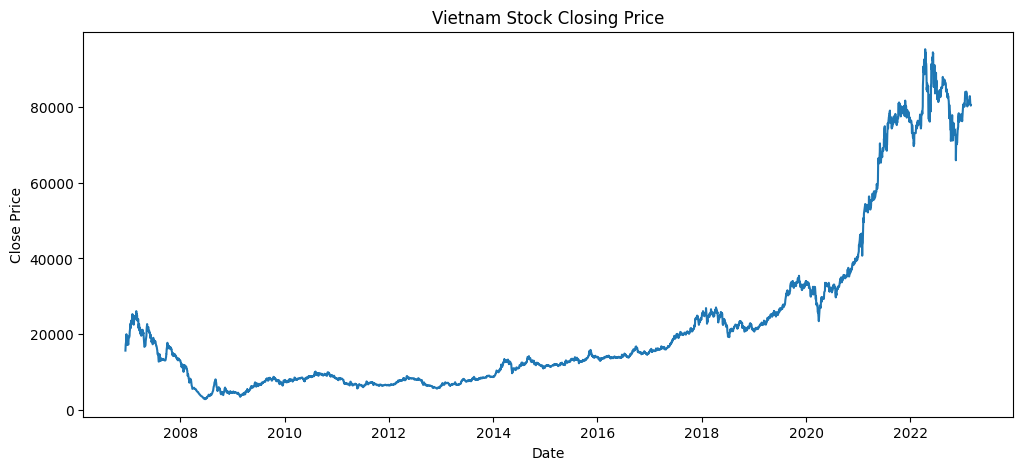

In [57]:
plt.figure(figsize=(12,5))

plt.plot(
    df["TradingDate"],
    df["Close"]
)

plt.title("Vietnam Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

In [58]:
features = [
    "Low",
    "Open",
    "Volume",
    "High",
    "Close"
]

target_col = "Close"

close_index = features.index(target_col)

data = df[features].copy()

data.head()

,Low,Open,Volume,High,Close
0,15710.0,15710.0,83530,15710.0,15710.0
1,16495.0,16495.0,280710,16495.0,16495.0
2,17320.0,17320.0,265300,17320.0,17320.0
3,18184.0,18184.0,215790,18184.0,18184.0
4,19087.0,19087.0,137520,19087.0,19087.0


In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(4038, 5)


In [60]:
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled_data)):

    X.append(
        scaled_data[i-window_size:i]
    )

    y.append(
        scaled_data[i, close_index]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(4008, 30, 5)
(4008,)


In [61]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(2805, 30, 5)
(601, 30, 5)
(602, 30, 5)


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.optimizers import Adam

In [63]:
model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(window_size, len(features))
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    Dropout(0.2)
)

model.add(
    Flatten()
)

model.add(
    Dense(64, activation='relu')
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()

d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,497 (228.50 KB)

 Trainable params: 58,497 (228.50 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [65]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.9802e-04 - mae: 0.0202 - val_loss: 3.2329e-04 - val_mae: 0.0141
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.8859e-04 - mae: 0.0133 - val_loss: 2.5790e-04 - val_mae: 0.0120
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7825e-04 - mae: 0.0114 - val_loss: 2.4436e-04 - val_mae: 0.0122
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4161e-04 - mae: 0.0105 - val_loss: 3.0396e-04 - val_mae: 0.0146
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1515e-04 - mae: 0.0096 - val_loss: 2.2726e-04 - val_mae: 0.0122
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7847e-04 - mae: 0.0089 - val_loss: 2.1286e-04 - val_mae: 0.0100
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6073e-04 - mae: 0.0084 - val_loss: 1.8761e-04 - val_mae: 0.0097
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6684e-04 - mae: 0.0086 - val_loss: 2.6056e-04 - val_mae: 0.0136


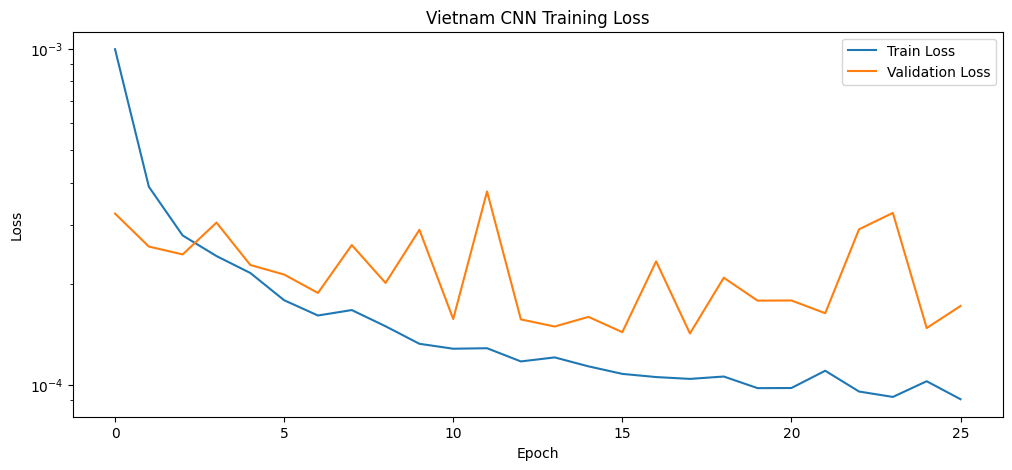

In [66]:
plt.figure(figsize=(12,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.yscale("log")

plt.title("Vietnam CNN Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [67]:
predictions = model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

mae = mean_absolute_error(
    y_test,
    predictions
)

print("RMSE:", rmse)
print("MAE:", mae)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RMSE: 0.03607908493413919
MAE: 0.027564243663335278


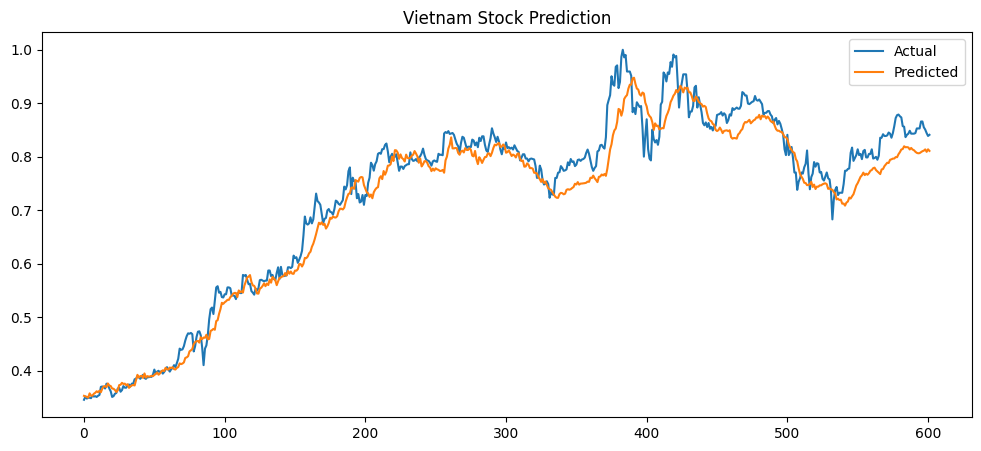

In [68]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("Vietnam Stock Prediction")

plt.legend()

plt.show()

In [69]:
# ============================================================
# Real-scale evaluation
# ============================================================

dummy_actual = np.zeros((len(y_test), len(features)))
dummy_pred = np.zeros((len(predictions), len(features)))

dummy_actual[:, close_index] = y_test
dummy_pred[:, close_index] = predictions.flatten()

actual_prices = scaler.inverse_transform(dummy_actual)[:, close_index]
predicted_prices = scaler.inverse_transform(dummy_pred)[:, close_index]

real_rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

real_mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("Real-scale RMSE:", real_rmse)
print("Real-scale MAE:", real_mae)

Real-scale RMSE: 3329.7026694867695
Real-scale MAE: 2543.876483445548


In [70]:
model.save("../models/task2_vietnam_cnn.keras")

In [71]:
task2_results = pd.DataFrame({
    "Model": ["CNN"],
    "RMSE_Normalized": [rmse],
    "MAE_Normalized": [mae],
    "RMSE_RealScale": [real_rmse],
    "MAE_RealScale": [real_mae]
})

task2_results.to_csv(
    "../results/task2_vietnam_results.csv",
    index=False
)

task2_results

,Model,RMSE_Normalized,MAE_Normalized,RMSE_RealScale,MAE_RealScale
0,CNN,0.036079,0.027564,3329.702669,2543.876483


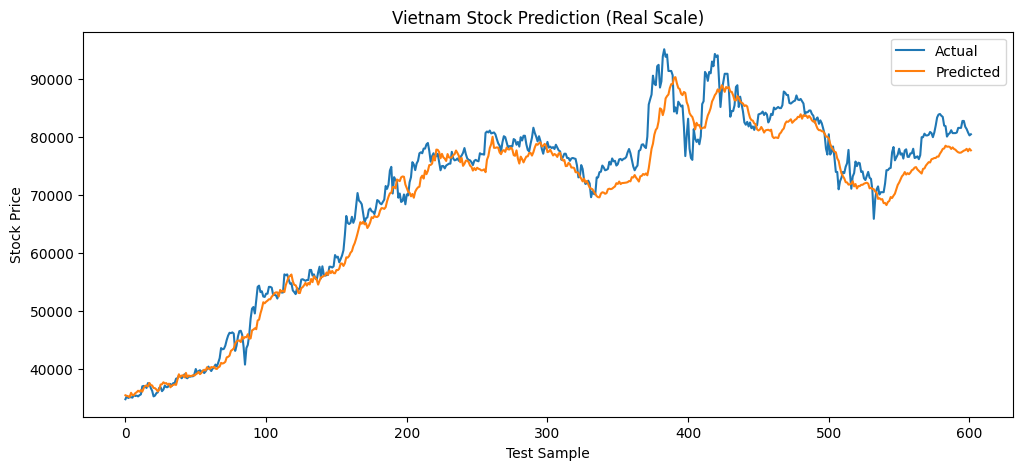

In [72]:
plt.figure(figsize=(12,5))

plt.plot(actual_prices, label="Actual")
plt.plot(predicted_prices, label="Predicted")

plt.title("Vietnam Stock Prediction (Real Scale)")

plt.xlabel("Test Sample")
plt.ylabel("Stock Price")

plt.legend()

plt.savefig(
    "../results/task2_vietnam_prediction.png"
)

plt.show()

In [73]:
# ============================================================
# Chronological Train / Validation / Test Split
# ============================================================

def chronological_split(X, y, train_ratio=0.7, val_ratio=0.15):

    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size + val_size]
    y_val = y[train_size:train_size + val_size]

    X_test = X[train_size + val_size:]
    y_test = y[train_size + val_size:]

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    )

In [75]:
# ============================================================
# CNN Model Builder
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

def build_cnn_model(window_size, num_features, output_size=1):

    model = Sequential([

        Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            input_shape=(window_size, num_features)
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.2),

        Flatten(),

        Dense(64, activation='relu'),

        Dropout(0.2),

        Dense(output_size)

    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [76]:
# ============================================================
# Task 2.2 - Vietnam kth-day forecast
# ============================================================

def create_kth_day_dataset(scaled_data, window_size, close_index, k):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(scaled_data[i-window_size:i])
        y.append(scaled_data[i + k - 1, close_index])

    return np.array(X), np.array(y)


k_day = 7

X_2_2, y_2_2 = create_kth_day_dataset(
    scaled_data,
    window_size,
    close_index,
    k_day
)

X_train_2_2, X_val_2_2, X_test_2_2, y_train_2_2, y_val_2_2, y_test_2_2 = chronological_split(
    X_2_2,
    y_2_2
)

model_2_2 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=1
)

history_2_2 = model_2_2.fit(
    X_train_2_2,
    y_train_2_2,
    validation_data=(X_val_2_2, y_val_2_2),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

pred_2_2 = model_2_2.predict(X_test_2_2)

rmse_2_2 = np.sqrt(mean_squared_error(y_test_2_2, pred_2_2))
mae_2_2 = mean_absolute_error(y_test_2_2, pred_2_2)

print("Task 2.2 RMSE:", rmse_2_2)
print("Task 2.2 MAE:", mae_2_2)

Epoch 1/100


d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.0282e-04 - val_loss: 6.4481e-04
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4878e-04 - val_loss: 0.0019
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8804e-04 - val_loss: 9.5791e-04
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.7956e-04 - val_loss: 3.7082e-04
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2628e-04 - val_loss: 4.9485e-04
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0736e-04 - val_loss: 4.8589e-04
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9734e-04 - val_loss: 3.9332e-04
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6696e-04 - val_loss: 3.2178e-04
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Task 2.2 RMSE: 0.04937636705544168
Task 2.2 MAE: 0.036928155567943974


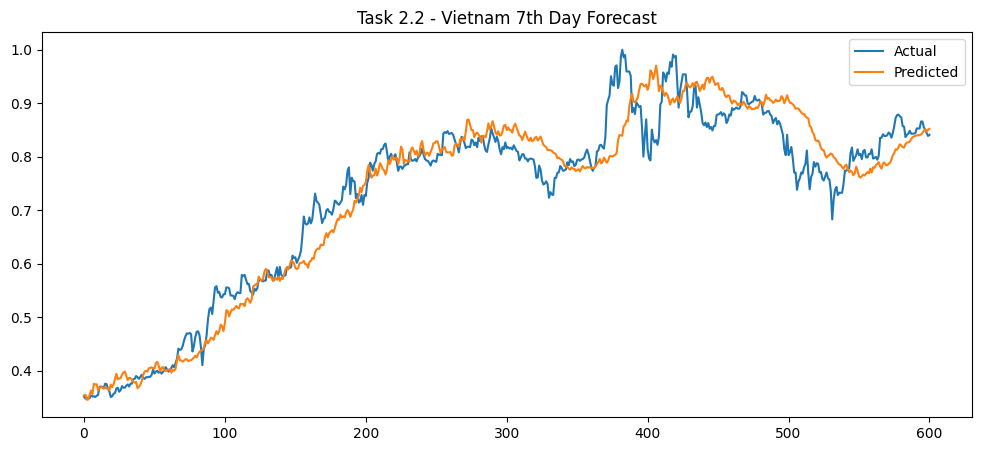

In [77]:
plt.figure(figsize=(12,5))
plt.plot(y_test_2_2, label="Actual")
plt.plot(pred_2_2, label="Predicted")
plt.title("Task 2.2 - Vietnam 7th Day Forecast")
plt.legend()
plt.show()

In [78]:
# ============================================================
# Task 2.3 - Vietnam k consecutive days forecast
# ============================================================

def create_k_days_dataset(scaled_data, window_size, close_index, k):
    X = []
    y = []

    for i in range(window_size, len(scaled_data) - k + 1):
        X.append(scaled_data[i-window_size:i])
        y.append(scaled_data[i:i+k, close_index])

    return np.array(X), np.array(y)


k_days = 7

X_2_3, y_2_3 = create_k_days_dataset(
    scaled_data,
    window_size,
    close_index,
    k_days
)

X_train_2_3, X_val_2_3, X_test_2_3, y_train_2_3, y_val_2_3, y_test_2_3 = chronological_split(
    X_2_3,
    y_2_3
)

model_2_3 = build_cnn_model(
    window_size=window_size,
    num_features=len(features),
    output_size=k_days
)

history_2_3 = model_2_3.fit(
    X_train_2_3,
    y_train_2_3,
    validation_data=(X_val_2_3, y_val_2_3),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

pred_2_3 = model_2_3.predict(X_test_2_3)

rmse_2_3 = np.sqrt(
    mean_squared_error(y_test_2_3.flatten(), pred_2_3.flatten())
)

mae_2_3 = mean_absolute_error(
    y_test_2_3.flatten(), pred_2_3.flatten()
)

print("Task 2.3 RMSE:", rmse_2_3)
print("Task 2.3 MAE:", mae_2_3)

Epoch 1/100


d:\Study Documents\Fulbright\2026 Spring\Deep Learning for Artificial Intelligence\DL_Final_Project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0014 - val_loss: 6.5611e-04
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.7976e-04 - val_loss: 0.0013
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6986e-04 - val_loss: 5.1450e-04
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9563e-04 - val_loss: 4.0170e-04
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.7016e-04 - val_loss: 5.5480e-04
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1851e-04 - val_loss: 2.7561e-04
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.0180e-04 - val_loss: 2.5564e-04
Epoch 8/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.9013e-04 - val_loss: 2.7045e-04
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Task 2.3 RMSE: 0.07304704434817594
Task 2.3 MAE: 0.059432285617604726


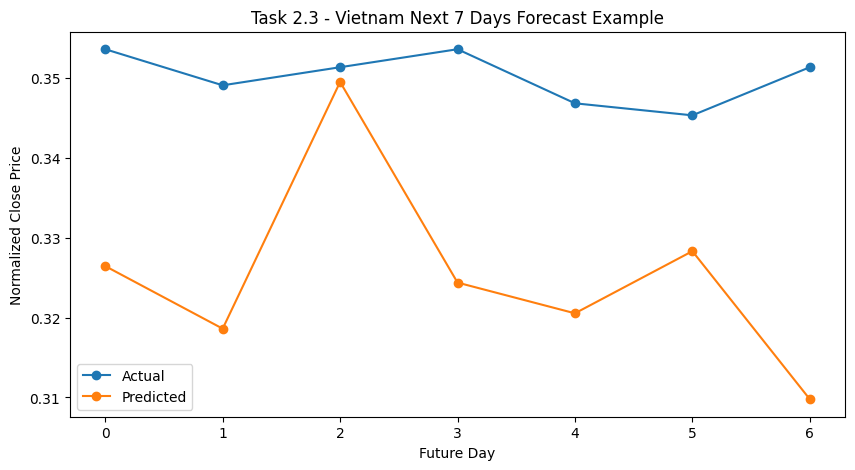

In [79]:
sample_index = 0

plt.figure(figsize=(10,5))
plt.plot(y_test_2_3[sample_index], marker="o", label="Actual")
plt.plot(pred_2_3[sample_index], marker="o", label="Predicted")
plt.title("Task 2.3 - Vietnam Next 7 Days Forecast Example")
plt.xlabel("Future Day")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.show()

In [80]:
task2_results = pd.DataFrame({
    "Task": [
        "Task 2.1 - Next-day prediction",
        "Task 2.2 - 7th day prediction",
        "Task 2.3 - Next 7 days prediction"
    ],
    "Model": [
        "CNN",
        "CNN",
        "CNN"
    ],
    "RMSE": [
        rmse,
        rmse_2_2,
        rmse_2_3
    ],
    "MAE": [
        mae,
        mae_2_2,
        mae_2_3
    ]
})

task2_results.to_csv("../results/task2_vietnam_results.csv", index=False)

task2_results

,Task,Model,RMSE,MAE
0,Task 2.1 - Next-day prediction,CNN,0.036079,0.027564
1,Task 2.2 - 7th day prediction,CNN,0.049376,0.036928
2,Task 2.3 - Next 7 days prediction,CNN,0.073047,0.059432


In [81]:
task2_results.to_csv("../results/task2_vietnam_results.csv", index=False)

model.save("../models/task2_1_vietnam_cnn.keras")
model_2_2.save("../models/task2_2_vietnam_cnn.keras")
model_2_3.save("../models/task2_3_vietnam_cnn.keras")